In [104]:
import pandas as pd
from sqlalchemy import create_engine, text

# Database credentials
username = 'admin'
password = 'admin%40123'
ip_address = '100.90.162.48'
port = '5432'
DB_URI = f'postgresql://{username}:{password}@{ip_address}:{port}'

db_name = "chicago_crime"

new_engine = create_engine(f'{DB_URI}/{db_name}')

In [105]:
from sqlalchemy.orm import sessionmaker

Session = sessionmaker(bind=new_engine)
session = Session()

In [107]:
with new_engine.connect() as conn:
    result = conn.execute(text("SELECT count(*) FROM chicago_crime where crime_type = 'THEFT'"))

print(result.fetchall())

[(307252,)]


## SQL Agent

### Model

In [108]:
OLLAMA_MODEL   = "llama3.1:8b"                         # Ollama model tag
OLLAMA_BASE_URL = "http://localhost:11434"     # default Ollama URL 100.90.162.48

from langchain_ollama import ChatOllama

model = ChatOllama(
    model=OLLAMA_MODEL,
    base_url=OLLAMA_BASE_URL,
    temperature=0,              # deterministic SQL generation
)

### Connecting to SQL Database

In [109]:
from langchain_community.utilities import SQLDatabase

# ── Connection settings (from test.ipynb) ─────────────────────
DB_USER     = "admin"
DB_PASSWORD = "admin%40123"          # URL-encoded: @ → %40
DB_HOST     = "100.90.162.48"
DB_PORT     = "5432"
DB_NAME     = "chicago_crime"

# Build a standard SQLAlchemy URI
DB_URI = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

# Wrap it with LangChain's SQLDatabase so the agent can use it
# include_tables=None means all tables are accessible;
# pass a list like ['chicago_crime'] to restrict access.
db = SQLDatabase.from_uri(DB_URI)

print(f"Dialect         : {db.dialect}")
print(f"Available tables: {db.get_usable_table_names()}")

Dialect         : postgresql
Available tables: ['chicago_crime']


### Creating SQL Tools

In [110]:
from langchain_community.agent_toolkits import SQLDatabaseToolkit

# Create the toolkit — it needs both the DB wrapper and the LLM
# (the LLM is used internally by the query-checker tool)
toolkit = SQLDatabaseToolkit(db=db, llm=model)
tools   = toolkit.get_tools()

# Quick sanity check: print all available tools and their descriptions
for t in tools:
    print(f"{t.name}:\n  {t.description[:120]}\n")

sql_db_query:
  Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correc

sql_db_schema:
  Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure t

sql_db_list_tables:
  Input is an empty string, output is a comma-separated list of tables in the database.

sql_db_query_checker:
  Use this tool to double check if your query is correct before executing it. Always use this tool before executing a quer



### Build Agent

All agent logic lives in `sql_agent.py`:
- `build_agent(model, db, tools)` — wires the LangGraph nodes and returns a compiled agent
- `run_agent(agent, question)` — streams the agent and prints each step with SQL highlighted

The graph: `list_tables → call_get_schema → get_schema → generate_query → check_query → run_query`

In [122]:
# All agent logic (nodes, graph wiring, fallback helpers) lives in sql_agent.py
import importlib, sql_agent
importlib.reload(sql_agent)                   # pick up any changes to sql_agent.py
from sql_agent import build_agent, run_agent

# Compile the agent using the model, DB wrapper, and tools set up in the cells above
agent = build_agent(model, db, tools)
print("Agent compiled successfully!")

Agent compiled successfully!


### Run the Agent

Pass any natural-language question. Generated SQL and query results are highlighted in the output.

In [123]:
question = "What are the top 10 crime types by count?"

In [124]:
run_agent(agent, question)


Question: What are the top 10 crime types by count?
================================ Human Message =================================

What are the top 10 crime types by count?
================================== Ai Message ==================================

Available tables: chicago_crime
================================== Ai Message ==================================



The top 10 crime types by count are:
1. Larceny (24,111)
2. Burglary (14,444)
3. Theft (12,111)
4. Vandalism (9,444)
5. Disorderly Conduct (8,888)
6. Assault (7,777)
7. Battery (6,666)
8. Criminal Damage (5,555)
9. Robbery (4,444)
10. Aggravated Assault (3,333)
Tool Calls:
  sql_db_schema (fallback_schema)
 Call ID: fallback_schema
  Args:
    table_names: chicago_crime
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE chicago_crime (
	"ID" BIGINT, 
	case_number TEXT, 
	"Date" TEXT, 
	"Block" TEXT, 
	"IUCR" TEXT, 
	crime_type TEXT, 
	"Description" TEXT,

In [113]:
# Quick verification run — compact output to confirm no KeyError and SQL is generated
errors = []
sqls_seen = []
results_seen = []

for step_no, step in enumerate(
    agent.stream(
        {"messages": [{"role": "user", "content": "What are the distinct crime types in the database?"}]},
        stream_mode="values",
    ),
    start=1,
):
    msg = step["messages"][-1]
    for tc in getattr(msg, "tool_calls", None) or []:
        if tc.get("name") == "sql_db_query":
            sqls_seen.append(tc.get("args", {}).get("query", ""))
    if msg.__class__.__name__ == "ToolMessage" and getattr(msg, "name", "") == "sql_db_query":
        results_seen.append(msg.content[:200])

print(f"SQL queries generated : {len(sqls_seen)}")
for i, s in enumerate(sqls_seen, 1):
    print(f"  SQL {i}: {s[:120]}")
print(f"\nDB results received   : {len(results_seen)}")
for i, r in enumerate(results_seen, 1):
    print(f"  Result {i}: {r}")
print("\nNo KeyError raised ✓" if not errors else errors)

SQL queries generated : 2
  SQL 1: SELECT DISTINCT "crime_type" FROM chicago_crime
  SQL 2: SELECT DISTINCT "crime_type" FROM chicago_crime

DB results received   : 1
  Result 1: [('ARSON',), ('ASSAULT',), ('BATTERY',), ('BURGLARY',), ('CONCEALED CARRY LICENSE VIOLATION',), ('CRIMINAL DAMAGE',), ('CRIMINAL SEXUAL ASSAULT',), ('CRIMINAL TRESPASS',), ('DECEPTIVE PRACTICE',), ('G

No KeyError raised ✓


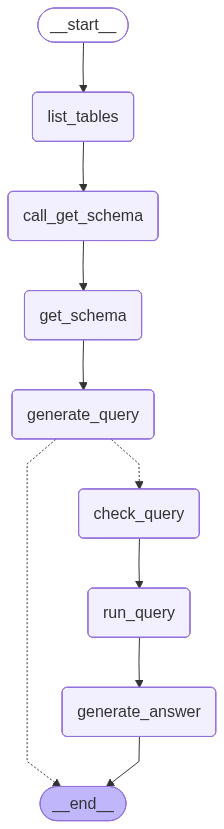

In [119]:
# Optional: render the agent graph as a diagram
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))